In [47]:
import xgboost as xgb
from torch.utils.data import Dataset, DataLoader
import torch
import json
import os 
import glob
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

In [ ]:
solar_dir = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/latest/2020/01/01')
files = [f for f in solar_dir.glob('*.nc')]
ds = xr.open_mfdataset(files)

ds_train = ds.sel(
    latitude=slice(-35, -30),
    longitude=slice(145, 150),
    time=slice('2019-12-31T23', '2020-01-01T07')
)
data = ds_train.surface_global_irradiance.values
data[np.isnan(data)] = 0

In [62]:
def create_dataset(data, n_lags=3, patch_radius=1):
    T, H, W = data.shape
    
    X_list = []
    y_list = []
    
    for t in range(n_lags, T):
        for i in range(patch_radius, H - patch_radius):
            for j in range(patch_radius, W - patch_radius):
                
                features = []
                
                # temporal + spatial features
                for lag in range(1, n_lags + 1):
                    patch = data[t - lag,
                                 i - patch_radius:i + patch_radius + 1,
                                 j - patch_radius:j + patch_radius + 1]
                    
                    features.extend(patch.flatten())
                
                X_list.append(features)
                y_list.append(data[t, i, j])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    return X, y

In [63]:
split_idx = int(0.8 * len(data))

train_data = data[:split_idx]
val_data   = data[split_idx:]

X_train, y_train = create_dataset(train_data)
X_val, y_val     = create_dataset(val_data)

In [64]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse",
    early_stopping_rounds=20
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-rmse:560.72339
[1]	validation_0-rmse:534.29520
[2]	validation_0-rmse:510.48039
[3]	validation_0-rmse:486.89703
[4]	validation_0-rmse:464.59544
[5]	validation_0-rmse:443.44925
[6]	validation_0-rmse:423.27961
[7]	validation_0-rmse:404.30942
[8]	validation_0-rmse:386.23283
[9]	validation_0-rmse:368.27273
[10]	validation_0-rmse:351.48644
[11]	validation_0-rmse:335.75023
[12]	validation_0-rmse:320.71503
[13]	validation_0-rmse:306.54805
[14]	validation_0-rmse:292.98009
[15]	validation_0-rmse:280.66514
[16]	validation_0-rmse:268.40146
[17]	validation_0-rmse:256.73451
[18]	validation_0-rmse:245.51936
[19]	validation_0-rmse:235.00450
[20]	validation_0-rmse:224.99482
[21]	validation_0-rmse:215.60409
[22]	validation_0-rmse:206.51894
[23]	validation_0-rmse:198.03363
[24]	validation_0-rmse:189.78580
[25]	validation_0-rmse:181.82985
[26]	validation_0-rmse:174.30362
[27]	validation_0-rmse:167.22368
[28]	validation_0-rmse:160.34899
[29]	validation_0-rmse:154.14135
[30]	validation_0-rm

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'rmse'


In [65]:
def predict_image(model, data, t, n_lags=3, patch_radius=1):
    H, W = data.shape[1:]
    pred = np.zeros((H, W))
    
    for i in range(patch_radius, H - patch_radius):
        for j in range(patch_radius, W - patch_radius):
            
            features = []
            
            for lag in range(1, n_lags + 1):
                patch = data[t - lag,
                             i - patch_radius:i + patch_radius + 1,
                             j - patch_radius:j + patch_radius + 1]
                features.extend(patch.flatten())
            
            pred[i, j] = model.predict(np.array(features).reshape(1, -1))
    
    return pred

In [66]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))

In [67]:
rmse

52.62092290232742

/jobfs/163848188.gadi-pbs/ipykernel_3064920/170894528.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files)
/jobfs/163848188.gadi-pbs/ipykernel_3064920/452974076.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred[i, j] = model.predict(np.array(features).reshape(1, -1))


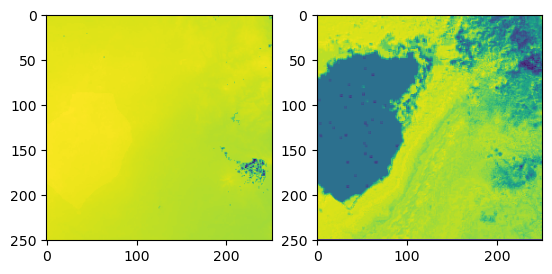

In [76]:
solar_dir = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/latest/2020/01/02')
files = [f for f in solar_dir.glob('*.nc')]
ds = xr.open_mfdataset(files)

ds_train = ds.sel(
    latitude=slice(-35, -30),
    longitude=slice(145, 150),
    time=slice('2020-01-01T23', '2020-01-02T07')
)
data = ds_train.surface_global_irradiance.values
data[np.isnan(data)] = 0

t = 20
prediction = predict_image(model, data, t)

fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(data[t, :, :])
ax[1].imshow(prediction)